In [1]:
# ==========================================================
# 1. Imports
# ==========================================================

import os
import re
import cv2
import torch
import random
import numpy as np
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from glob import glob
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ==========================================================
# 2. Gabor Filter Bank (UNCHANGED)
# ==========================================================

def build_gabor_bank():
    kernels = []
    for theta in np.arange(0, np.pi, np.pi / 8):
        for sigma in (2, 4, 6):
            kernels.append(cv2.getGaborKernel((21, 21), sigma, theta, 10, 0.5))
    return kernels

gabor_kernels = build_gabor_bank()

def apply_gabor(img):
    img = np.array(img.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    responses = [cv2.filter2D(gray, cv2.CV_32F, k) for k in gabor_kernels]
    r = np.max(np.stack(responses), axis=0)
    r = cv2.normalize(r, None, 0, 255, cv2.NORM_MINMAX)

    return Image.fromarray(r.astype(np.uint8))


# ==========================================================
# 3. Transforms (UNCHANGED)
# ==========================================================

cls_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])


# ==========================================================
# 4. Label Extraction (UNCHANGED)
# ==========================================================

def extract_label(name):
    if re.search("malignant", name, re.I):
        return 1
    if re.search("benign", name, re.I):
        return 0
    return -1


# ==========================================================
# 5. Dataset (UNCHANGED)
# ==========================================================

class ThermoDataset(Dataset):
    def __init__(self, folder):
        self.files = glob(folder + "/*")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = Image.open(path)
        img = apply_gabor(img)
        img = cls_transform(img)
        label = extract_label(path)
        return img, label


# ==========================================================
# 6. Baseline Models
# ==========================================================

# --- LeNet-5 ---
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, 5),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(6, 16, 5),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Flatten(),
            nn.Linear(16*53*53, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 2)
        )

    def forward(self, x):
        return self.net(x)


# --- AlexNet ---
def get_alexnet():
    model = torchvision.models.alexnet(weights=None)
    model.features[0] = nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2)
    model.classifier[6] = nn.Linear(4096, 2)
    return model


# --- VGG19 ---
def get_vgg19():
    model = torchvision.models.vgg19(weights=None)
    model.features[0] = nn.Conv2d(1, 64, kernel_size=3, padding=1)
    model.classifier[6] = nn.Linear(4096, 2)
    return model


# --- ResNet50 ---
def get_resnet50():
    model = torchvision.models.resnet50(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(2048, 2)
    return model


# ==========================================================
# 7. Training Function (GENERIC)
# ==========================================================

def train_model(model, train_loader, val_loader, name, epochs=60):

    model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    ce = nn.CrossEntropyLoss()

    best_val_acc = 0

    for epoch in range(epochs):

        model.train()
        preds, gts = [], []
        total_loss = 0

        for img, label in train_loader:

            img, label = img.to(device), label.to(device)

            out = model(img)
            loss = ce(out, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds += out.argmax(1).cpu().tolist()
            gts   += label.cpu().tolist()

        train_acc = accuracy_score(gts, preds)

        # Validation
        model.eval()
        v_preds, v_gts = [], []

        with torch.no_grad():
            for img, label in val_loader:
                img = img.to(device)
                out = model(img)
                v_preds += out.argmax(1).cpu().tolist()
                v_gts   += label.tolist()

        val_acc = accuracy_score(v_gts, v_preds)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(),
                       f"/kaggle/working/{name}_best.pth")

        print(f"{name} | Epoch {epoch} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    print(f"{name} training complete. Best Val Acc: {best_val_acc:.4f}")


# ==========================================================
# 8. Evaluation (UNCHANGED)
# ==========================================================

def evaluate(model, loader):

    model.eval()
    preds, gts = [], []

    with torch.no_grad():
        for img, label in loader:
            img = img.to(device)

            out1 = model(img)
            out2 = model(torch.flip(img, [3]))
            out3 = model(torch.flip(img, [2]))

            out = (out1 + out2 + out3) / 3

            preds += out.argmax(1).cpu().tolist()
            gts   += label.tolist()

    acc = accuracy_score(gts, preds)
    f1  = f1_score(gts, preds)

    print("Test Accuracy:", acc)
    print("F1 Score:", f1)

    cm = confusion_matrix(gts, preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Benign","Malignant"],
                yticklabels=["Benign","Malignant"])
    plt.show()

    print(classification_report(gts, preds))

In [2]:
# ==========================================================
# 9. DataLoaders (UNCHANGED BATCH SIZE)
# ==========================================================

train_loader = DataLoader(
    ThermoDataset("/kaggle/input/datasets/lilyofthevalley6666/correctly-preprocessed-bt-images-80-20-fs/train_i"),
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    ThermoDataset("/kaggle/input/datasets/lilyofthevalley6666/correctly-preprocessed-bt-images-80-20-fs/val_i"),
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    ThermoDataset("/kaggle/input/datasets/lilyofthevalley6666/correctly-preprocessed-bt-images-80-20-fs/test_i"),
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


===== Training LeNet5 =====

LeNet5 | Epoch 0 | Train Acc: 0.5323 | Val Acc: 0.5000
LeNet5 | Epoch 1 | Train Acc: 0.6567 | Val Acc: 0.4722
LeNet5 | Epoch 2 | Train Acc: 0.6940 | Val Acc: 0.5208
LeNet5 | Epoch 3 | Train Acc: 0.7305 | Val Acc: 0.4444
LeNet5 | Epoch 4 | Train Acc: 0.7430 | Val Acc: 0.4792
LeNet5 | Epoch 5 | Train Acc: 0.7861 | Val Acc: 0.4514
LeNet5 | Epoch 6 | Train Acc: 0.8043 | Val Acc: 0.4306
LeNet5 | Epoch 7 | Train Acc: 0.8226 | Val Acc: 0.4792
LeNet5 | Epoch 8 | Train Acc: 0.8391 | Val Acc: 0.4514
LeNet5 | Epoch 9 | Train Acc: 0.8665 | Val Acc: 0.5208
LeNet5 | Epoch 10 | Train Acc: 0.9005 | Val Acc: 0.4792
LeNet5 | Epoch 11 | Train Acc: 0.9146 | Val Acc: 0.5486
LeNet5 | Epoch 12 | Train Acc: 0.9295 | Val Acc: 0.5208
LeNet5 | Epoch 13 | Train Acc: 0.9577 | Val Acc: 0.5069
LeNet5 | Epoch 14 | Train Acc: 0.9660 | Val Acc: 0.5694
LeNet5 | Epoch 15 | Train Acc: 0.9867 | Val Acc: 0.5833
LeNet5 | Epoch 16 | Train Acc: 0.9884 | Val Acc: 0.5486
LeNet5 | Epoch 17 | Train Ac

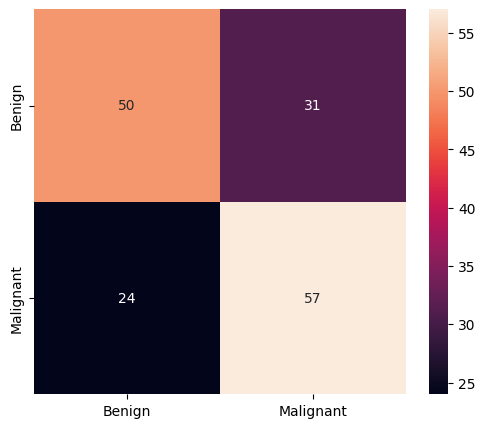

              precision    recall  f1-score   support

           0       0.68      0.62      0.65        81
           1       0.65      0.70      0.67        81

    accuracy                           0.66       162
   macro avg       0.66      0.66      0.66       162
weighted avg       0.66      0.66      0.66       162


===== Training AlexNet =====

AlexNet | Epoch 0 | Train Acc: 0.4818 | Val Acc: 0.5000
AlexNet | Epoch 1 | Train Acc: 0.5547 | Val Acc: 0.4444
AlexNet | Epoch 2 | Train Acc: 0.6575 | Val Acc: 0.5278
AlexNet | Epoch 3 | Train Acc: 0.7048 | Val Acc: 0.5208
AlexNet | Epoch 4 | Train Acc: 0.7255 | Val Acc: 0.6319
AlexNet | Epoch 5 | Train Acc: 0.7521 | Val Acc: 0.6319
AlexNet | Epoch 6 | Train Acc: 0.7811 | Val Acc: 0.6458
AlexNet | Epoch 7 | Train Acc: 0.7794 | Val Acc: 0.6458
AlexNet | Epoch 8 | Train Acc: 0.8267 | Val Acc: 0.6042
AlexNet | Epoch 9 | Train Acc: 0.8640 | Val Acc: 0.6597
AlexNet | Epoch 10 | Train Acc: 0.8872 | Val Acc: 0.5694
AlexNet | Epoch 11 | Trai

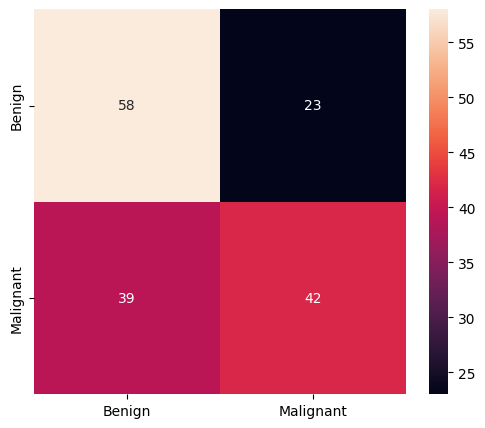

              precision    recall  f1-score   support

           0       0.60      0.72      0.65        81
           1       0.65      0.52      0.58        81

    accuracy                           0.62       162
   macro avg       0.62      0.62      0.61       162
weighted avg       0.62      0.62      0.61       162


===== Training VGG19 =====

VGG19 | Epoch 0 | Train Acc: 0.4917 | Val Acc: 0.5000
VGG19 | Epoch 1 | Train Acc: 0.5133 | Val Acc: 0.5000
VGG19 | Epoch 2 | Train Acc: 0.5265 | Val Acc: 0.5000
VGG19 | Epoch 3 | Train Acc: 0.5398 | Val Acc: 0.5000
VGG19 | Epoch 4 | Train Acc: 0.5000 | Val Acc: 0.5000
VGG19 | Epoch 5 | Train Acc: 0.4934 | Val Acc: 0.5000
VGG19 | Epoch 6 | Train Acc: 0.5075 | Val Acc: 0.5000
VGG19 | Epoch 7 | Train Acc: 0.5017 | Val Acc: 0.5000
VGG19 | Epoch 8 | Train Acc: 0.5000 | Val Acc: 0.5000
VGG19 | Epoch 9 | Train Acc: 0.5000 | Val Acc: 0.5000
VGG19 | Epoch 10 | Train Acc: 0.4743 | Val Acc: 0.5000
VGG19 | Epoch 11 | Train Acc: 0.5282 | Val Acc: 0

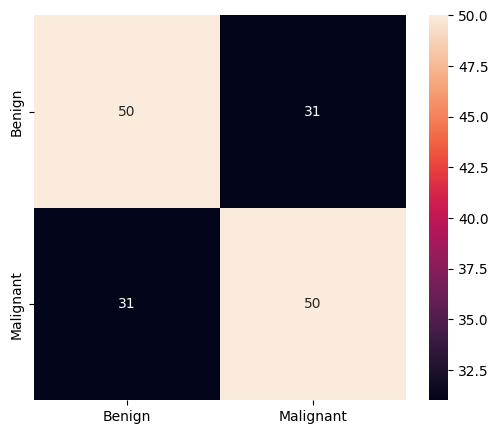

              precision    recall  f1-score   support

           0       0.62      0.62      0.62        81
           1       0.62      0.62      0.62        81

    accuracy                           0.62       162
   macro avg       0.62      0.62      0.62       162
weighted avg       0.62      0.62      0.62       162


===== Training ResNet50 =====

ResNet50 | Epoch 0 | Train Acc: 0.5920 | Val Acc: 0.4792
ResNet50 | Epoch 1 | Train Acc: 0.7172 | Val Acc: 0.6181
ResNet50 | Epoch 2 | Train Acc: 0.7604 | Val Acc: 0.5139
ResNet50 | Epoch 3 | Train Acc: 0.8275 | Val Acc: 0.6458
ResNet50 | Epoch 4 | Train Acc: 0.8872 | Val Acc: 0.6389
ResNet50 | Epoch 5 | Train Acc: 0.8706 | Val Acc: 0.5903
ResNet50 | Epoch 6 | Train Acc: 0.9121 | Val Acc: 0.6319
ResNet50 | Epoch 7 | Train Acc: 0.9403 | Val Acc: 0.6319
ResNet50 | Epoch 8 | Train Acc: 0.9345 | Val Acc: 0.5625
ResNet50 | Epoch 9 | Train Acc: 0.9411 | Val Acc: 0.5833
ResNet50 | Epoch 10 | Train Acc: 0.9585 | Val Acc: 0.7083
ResNet50 | Ep

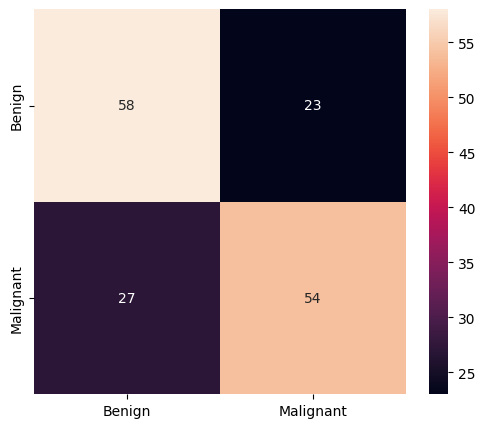

              precision    recall  f1-score   support

           0       0.68      0.72      0.70        81
           1       0.70      0.67      0.68        81

    accuracy                           0.69       162
   macro avg       0.69      0.69      0.69       162
weighted avg       0.69      0.69      0.69       162

All models trained and saved.


In [3]:
# ==========================================================
# 10. Main Execution (SEQUENTIAL TRAINING)
# ==========================================================

models = {
    "LeNet5": LeNet5(),
    "AlexNet": get_alexnet(),
    "VGG19": get_vgg19(),
    "ResNet50": get_resnet50()
}

for name, model in models.items():

    print(f"\n===== Training {name} =====\n")

    train_model(model, train_loader, val_loader, name, epochs=60)

    print(f"\n===== Evaluating {name} =====\n")

    model.load_state_dict(torch.load(f"/kaggle/working/{name}_best.pth"))
    evaluate(model, test_loader)

    torch.save(model.state_dict(),
               f"/kaggle/working/{name}_final.pth")

print("All models trained and saved.")